In [123]:
FEATURE_NAMES = [
	"pos_carro",       # posición horizontal del carro
	"vel_carro",       # velocidad horizontal del carro
	"angulo_palo",     # ángulo del palo respecto a la vertical
	"vel_ang_palo",    # velocidad angular del palo
]

ACTION_NAMES = [
	"izquierda",   # 0: empujar carro a la izquierda
	"derecha",     # 1: empujar carro a la derecha
]

In [124]:
import torch
import numpy as np
import gymnasium as gym
import shap
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
from dqn import DQNAgent, DQNNetwork
from stable_baselines3 import A2C
from visualization import show_animation_with_decision_path
from IPython.display import HTML
from lmut import LMUT
import os


In [125]:
env = gym.make('CartPole-v1', render_mode="rgb_array")

state_size = env.observation_space.shape[0]
action_size = env.action_space.n

print(state_size, action_size)


4 2


In [126]:
def evaluar_politica_arbol(env: gym.Env, tree: DecisionTreeClassifier, n_episodes: int = 20):
	rewards = []
	for _ in range(n_episodes):
		obs, _ = env.reset()
		done, total = False, 0.0
		while not done:
			action = int(tree.predict(obs.reshape(1, -1))[0])
			obs, r, term, trunc, _ = env.step(action)
			total += r
			done = term or trunc
		rewards.append(total)
	return np.mean(rewards), np.std(rewards)


In [127]:
def explain_action_tree(state: np.ndarray, tree: DecisionTreeClassifier, feature_names: list[str]):
    node_ids = tree.decision_path(state.reshape(1, -1)).indices
    rules = []
    for node in node_ids[:-1]:
        feat = feature_names[tree.tree_.feature[node]]
        thr = tree.tree_.threshold[node]
        val = state[tree.tree_.feature[node]]
        rules.append((feat, "<=" if val <= thr else ">", thr, val))

    action_taken = tree.predict(state.reshape(1, -1))[0]
    return action_taken, rules


# DQN

In [128]:
models_dir = "./models"

final_model_path = os.path.join(models_dir, "dqn_cartpole")

data_dir = "./data"
a2c_data_dir = os.path.join(data_dir, "dqn")

x_path = os.path.join(a2c_data_dir, "X_cartpole.npy")
y_path = os.path.join(a2c_data_dir, "y_cartpole.npy")

print(final_model_path)


./models\dqn_cartpole


In [129]:
agent = DQNAgent(state_size, action_size)
agent.load(final_model_path)

X = np.load(x_path)
y = np.load(y_path)


In [130]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)


In [131]:
explainer = shap.KernelExplainer(
    agent.predict_batch, 
    shap.sample(X_train, 1000)
)

shap_values = explainer.shap_values(X_test[:500])


Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 500/500 [00:06<00:00, 79.31it/s]


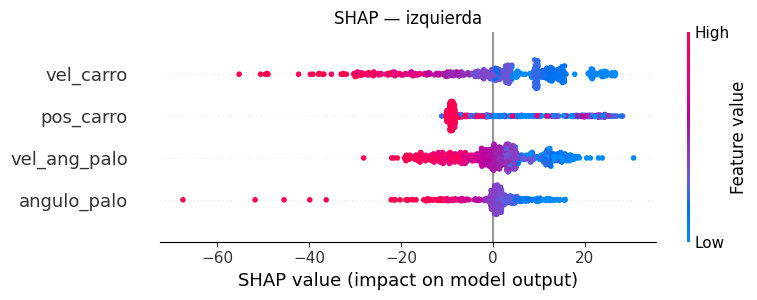

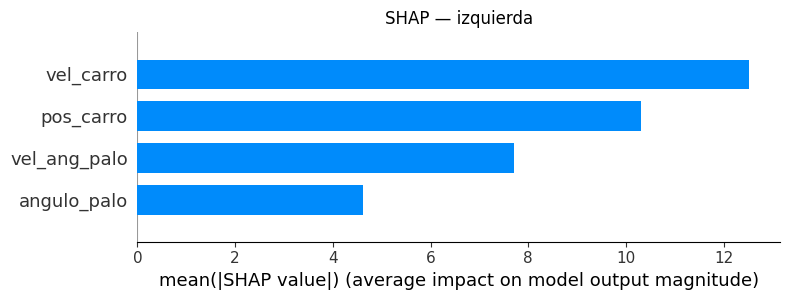

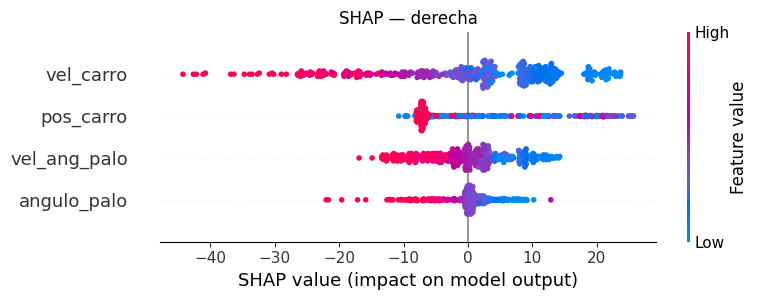

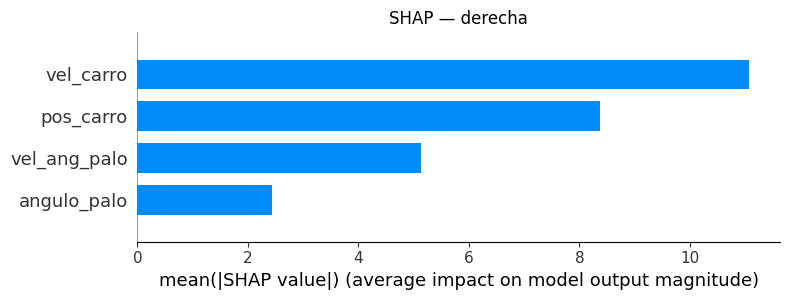

In [132]:
shap_arr = np.array(shap_values)

for i in range(len(ACTION_NAMES)):
	shap.summary_plot(shap_arr[:, :, i], X_test[:500],feature_names=FEATURE_NAMES, show=False)
	plt.title(f"SHAP — {ACTION_NAMES[i]}")
	plt.tight_layout()
	plt.show()

	shap.summary_plot(shap_arr[:, :, i], X_test[:500],feature_names=FEATURE_NAMES, plot_type="bar", show=False)
	plt.title(f"SHAP — {ACTION_NAMES[i]}")
	plt.tight_layout()
	plt.show()


In [133]:
tree = DecisionTreeClassifier(max_depth=6)
tree.fit(X_train, y_train)

print(f"Fidelidad (accuracy vs DQN): {accuracy_score(y_test, tree.predict(X_test)):.3f}")
print(classification_report(y_test, tree.predict(X_test), target_names=ACTION_NAMES))


Fidelidad (accuracy vs DQN): 0.882
              precision    recall  f1-score   support

   izquierda       0.88      0.88      0.88      5000
     derecha       0.88      0.88      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [134]:
for d in [2, 3, 4, 5, 6, 8, 10, 15, 20]:
	t = DecisionTreeClassifier(max_depth=d).fit(X_train, y_train)
	print(f"depth={d:2d}  fidelidad={accuracy_score(y_test, t.predict(X_test)):.3f}")


depth= 2  fidelidad=0.792
depth= 3  fidelidad=0.824
depth= 4  fidelidad=0.852
depth= 5  fidelidad=0.872
depth= 6  fidelidad=0.882
depth= 8  fidelidad=0.910
depth=10  fidelidad=0.924
depth=15  fidelidad=0.934
depth=20  fidelidad=0.935


|--- vel_ang_palo <= -0.01
|   |--- angulo_palo <= 0.00
|   |   |--- vel_ang_palo <= -0.13
|   |   |   |--- vel_ang_palo <= -0.18
|   |   |   |   |--- pos_carro <= 0.20
|   |   |   |   |   |--- vel_carro <= 0.65
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- vel_carro >  0.65
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- pos_carro >  0.20
|   |   |   |   |   |--- vel_carro <= 0.06
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- vel_carro >  0.06
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- vel_ang_palo >  -0.18
|   |   |   |   |--- pos_carro <= 1.56
|   |   |   |   |   |--- pos_carro <= 1.19
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- pos_carro >  1.19
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- pos_carro >  1.56
|   |   |   |   |   |--- pos_carro <= 1.59
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- pos_carro >  1.59
|   |   |   |   |   |   |--- class: 0
|   |   |--- vel_ang_palo >

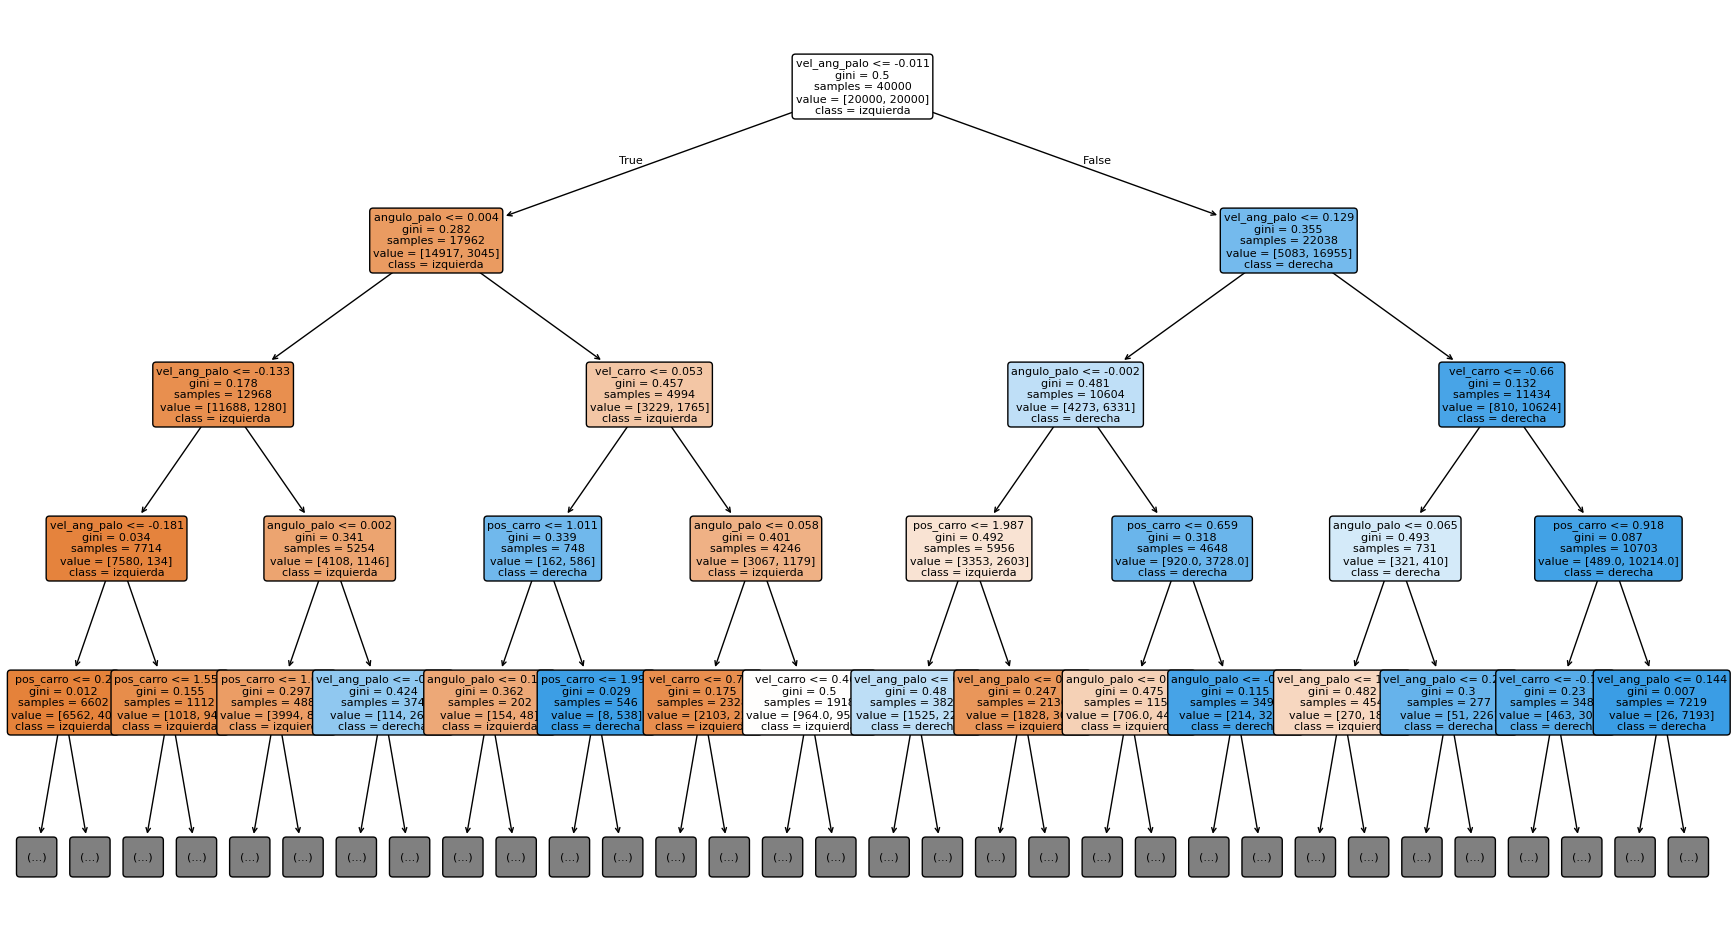

In [135]:
print(export_text(tree, feature_names=FEATURE_NAMES))

plt.figure(figsize=(22, 12))
plot_tree(
	tree,
	feature_names=FEATURE_NAMES,
	class_names=ACTION_NAMES,
	filled=True,
	rounded=True,
	fontsize=8,
	max_depth=4,  # recorta el dibujo para que sea legible
)
plt.show()


In [136]:
m, s = evaluar_politica_arbol(env, tree)
print(f"Recompensa del árbol sustituto: {m:.1f} ± {s:.1f}")


Recompensa del árbol sustituto: 287.4 ± 86.5


vel_ang_palo    0.657522
angulo_palo     0.158430
pos_carro       0.124597
vel_carro       0.059451
dtype: float64


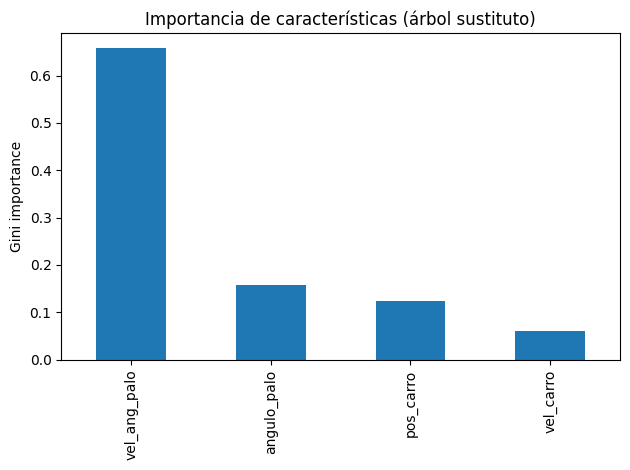

In [137]:
imp = pd.Series(tree.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
print(imp)

imp.plot(kind="bar", title="Importancia de características (árbol sustituto)", ylabel="Gini importance")
plt.tight_layout()
plt.savefig("importancia_cartpole.png", dpi=150)
plt.show()


# A2C

In [138]:
a2c_path = os.path.join(models_dir, "a2c")

data_dir = "./data"
a2c_data_dir = os.path.join(data_dir, "a2c")
os.makedirs(a2c_data_dir, exist_ok=True)

x_path = os.path.join(a2c_data_dir, "X_cartpole.npy")
y_path = os.path.join(a2c_data_dir, "y_cartpole.npy")


In [139]:
best_model = A2C.load(a2c_path)

X = np.load(x_path)
y = np.load(y_path)


c:\Users\malos\Documents\GitHub\XRL\.venv\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [140]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)


In [141]:
def politica_proba(obs_batch):
    device = best_model.policy.device
    obs_t = torch.as_tensor(obs_batch, dtype=torch.float32, device=device)
    dist = best_model.policy.get_distribution(obs_t)
    probs = dist.distribution.probs.detach().cpu().numpy()
    return probs[:, 1]

explainer = shap.KernelExplainer(politica_proba, shap.sample(X_train, 10000))
shap_values = explainer.shap_values(X_test[:500])
print("SHAP values calculados. Tipo:", type(shap_values))


Using 10000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 500/500 [00:08<00:00, 59.37it/s]

SHAP values calculados. Tipo: <class 'numpy.ndarray'>


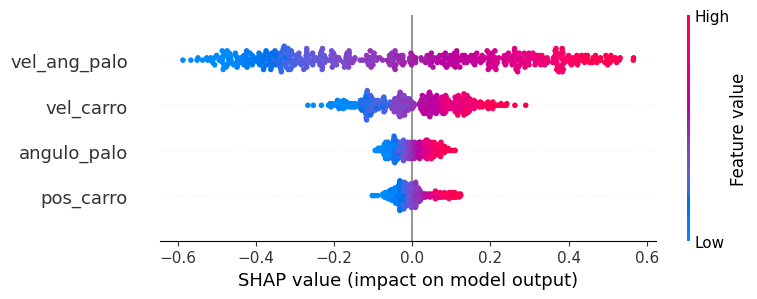

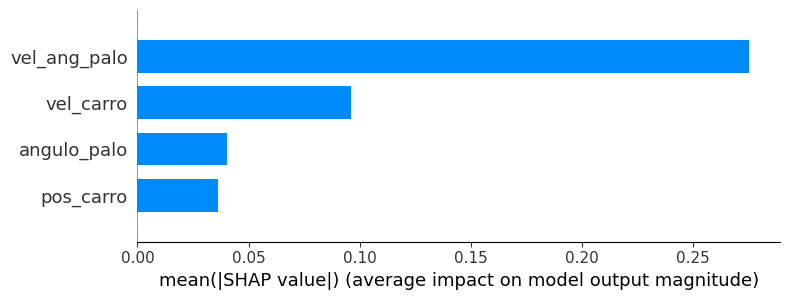

In [142]:
shap.summary_plot(shap_values, X_test[:500], feature_names=FEATURE_NAMES)
shap.summary_plot(shap_values, X_test[:500], feature_names=FEATURE_NAMES, plot_type="bar")


In [143]:
tree = DecisionTreeClassifier(max_depth=6)
tree.fit(X_train, y_train)

print(f"Fidelidad (accuracy vs A2C): {accuracy_score(y_test, tree.predict(X_test)):.3f}")
print(classification_report(y_test, tree.predict(X_test), target_names=ACTION_NAMES))


Fidelidad (accuracy vs A2C): 0.964
              precision    recall  f1-score   support

   izquierda       0.96      0.96      0.96      9998
     derecha       0.96      0.96      0.96     10002

    accuracy                           0.96     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.96      0.96      0.96     20000



In [144]:
# Barrido de profundidades para elegir el mejor trade-off
for d in [2, 3, 4, 5, 6, 8, 10, 15, 20]:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    print(f"depth={d:2d}  fidelidad={accuracy_score(y_test, t.predict(X_test)):.3f}")


depth= 2  fidelidad=0.888
depth= 3  fidelidad=0.940
depth= 4  fidelidad=0.943
depth= 5  fidelidad=0.958
depth= 6  fidelidad=0.964
depth= 8  fidelidad=0.978
depth=10  fidelidad=0.984
depth=15  fidelidad=0.985
depth=20  fidelidad=0.985


|--- vel_ang_palo <= -0.01
|   |--- vel_ang_palo <= -0.08
|   |   |--- vel_ang_palo <= -0.13
|   |   |   |--- vel_ang_palo <= -0.14
|   |   |   |   |--- vel_carro <= 0.60
|   |   |   |   |   |--- vel_ang_palo <= -0.15
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- vel_ang_palo >  -0.15
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- vel_carro >  0.60
|   |   |   |   |   |--- vel_ang_palo <= -0.18
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- vel_ang_palo >  -0.18
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- vel_ang_palo >  -0.14
|   |   |   |   |--- vel_carro <= 0.41
|   |   |   |   |   |--- pos_carro <= -0.01
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- pos_carro >  -0.01
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- vel_carro >  0.41
|   |   |   |   |   |--- angulo_palo <= -0.01
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- angulo_palo >  -0.01
|   |   |   |   |   |   |--- class: 1
|

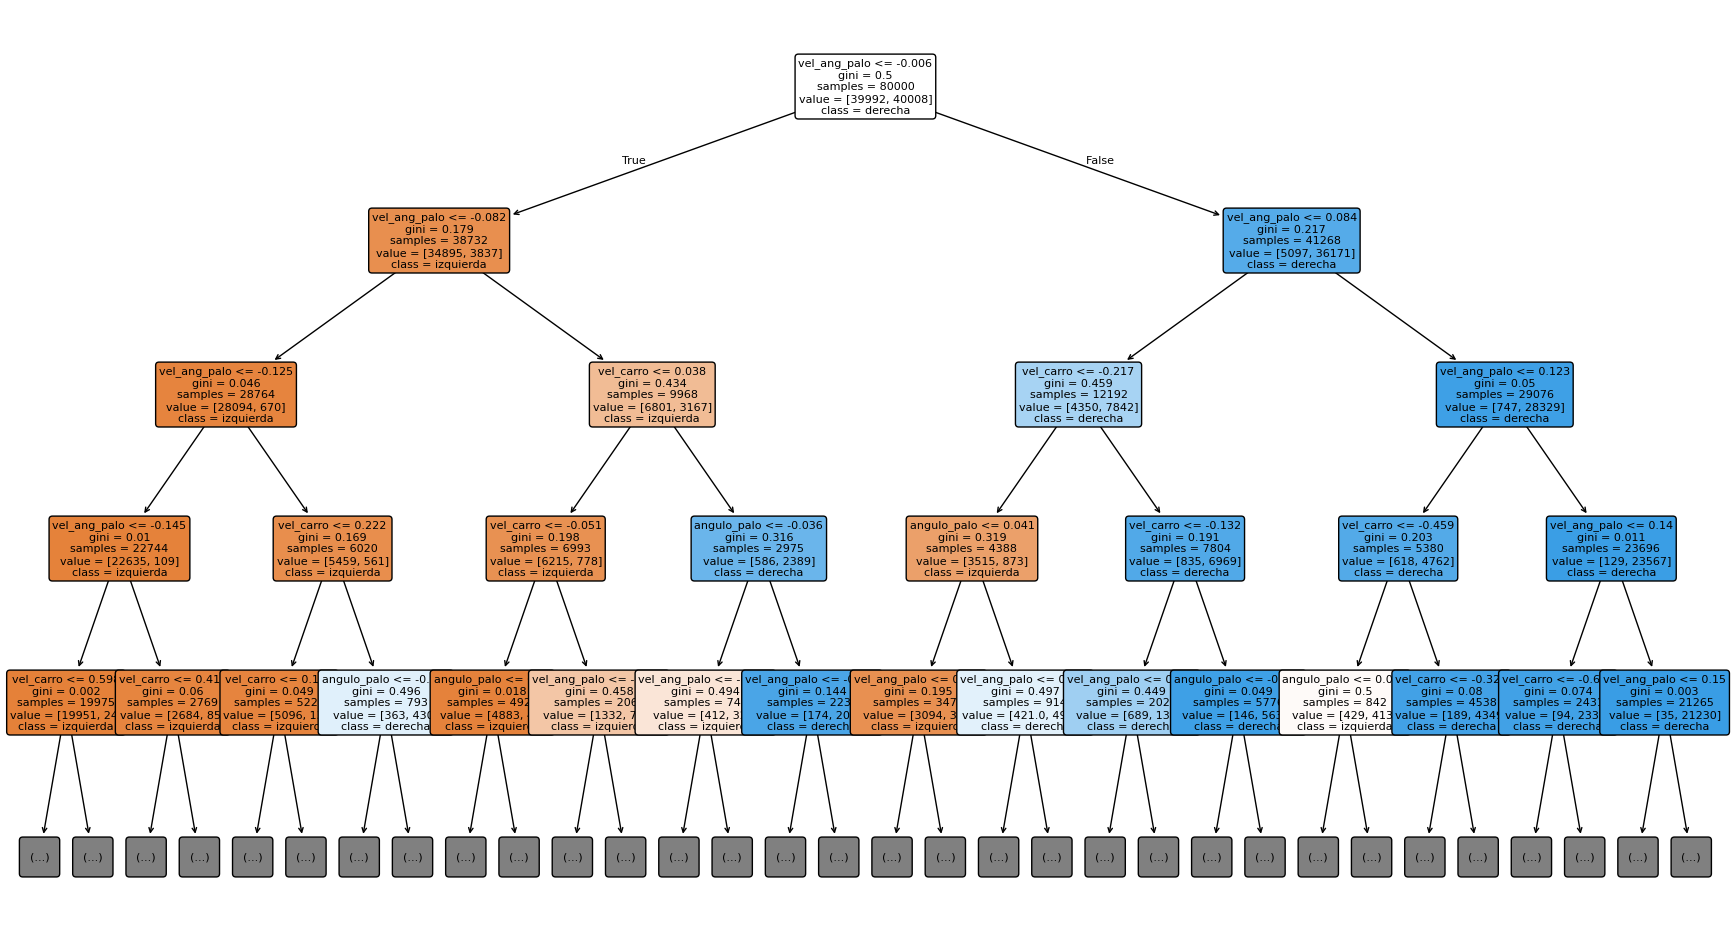

In [145]:
# Reglas legibles en texto
print(export_text(tree, feature_names=FEATURE_NAMES))

# Árbol gráfico
plt.figure(figsize=(22, 12))
plot_tree(
    tree,
    feature_names=FEATURE_NAMES,
    class_names=ACTION_NAMES,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4,  # recorta el dibujo para que sea legible
)
plt.show()


In [146]:
m, s = evaluar_politica_arbol(env, tree)
print(f"Recompensa del árbol sustituto: {m:.1f} ± {s:.1f}")


Recompensa del árbol sustituto: 466.1 ± 55.4


vel_ang_palo    0.782503
vel_carro       0.175237
angulo_palo     0.030445
pos_carro       0.011814
dtype: float64


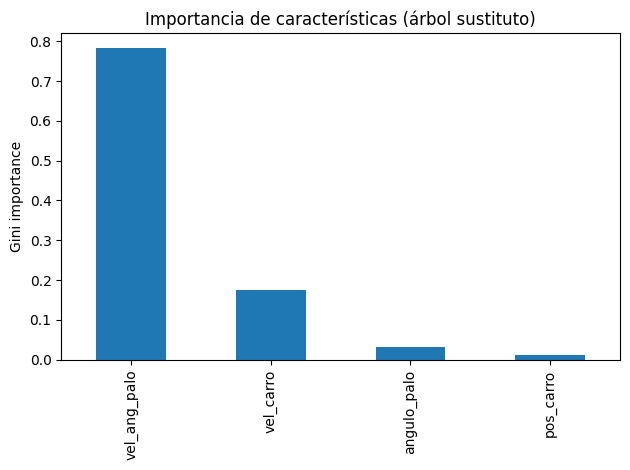

In [147]:
imp = pd.Series(tree.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
print(imp)

imp.plot(kind="bar", title="Importancia de características (árbol sustituto)", ylabel="Gini importance")
plt.tight_layout()
plt.show()


In [148]:
env = gym.make("CartPole-v1", render_mode="rgb_array")

frames, explanations = [], []
state, _ = env.reset()
state = np.array(state, dtype=np.float32)
done = False

while not done:
    frames.append(env.render())
    action, _ = best_model.predict(state, deterministic=True)
    action_taken, rules = explain_action_tree(state,tree, FEATURE_NAMES)
    explanations.append({"action": ACTION_NAMES[action], "rules": rules})
    state, reward, terminated, truncated, _ = env.step(action)
    state = np.array(state, dtype=np.float32)
    done = terminated or truncated

env.close()


In [149]:
ani = show_animation_with_decision_path(frames[:10], explanations[:10])

HTML(ani.to_jshtml())


# LMUT

In [150]:
lmut_path = os.path.join(models_dir, "lmut")


In [151]:
lmut2 = LMUT.load(lmut_path)


In [152]:
lmut2.print_tree(0)



=== Tree for action 0 ===
[Node] depth=0 | split: feature 2 < 0.0339
  left:
    [Node] depth=1 | split: feature 3 < -0.5969
      left:
        [Node] depth=2 | split: feature 2 < -0.1404
          left:
            [Node] depth=3 | split: feature 3 < -1.1224
              left:
                [Leaf] depth=4 | y = [-0.25606263 -2.9763227   0.8535153   5.4411955 ] * s + -3.4513
              right:
                [Node] depth=4 | split: feature 2 < -0.1747
                  left:
                    [Leaf] depth=5 | y = [-0.28694424 -1.7148706   0.9133243   5.064696  ] * s + -2.5158
                  right:
                    [Leaf] depth=5 | y = [-0.7009262 -1.2969786  0.7360002  4.297541 ] * s + -1.2241
          right:
            [Node] depth=3 | split: feature 3 < -1.1691
              left:
                [Node] depth=4 | split: feature 2 < -0.0955
                  left:
                    [Leaf] depth=5 | y = [ 0.0769522  -0.7658461   0.36850435  1.3220507 ] * s + -0.4749

In [153]:
print("\n=== Feature Influence ===")
for i, inf in enumerate(lmut2.feature_influence):
	print(f"{FEATURE_NAMES[i]} : {inf:.6f}")
	


=== Feature Influence ===
pos_carro : 11.449128
vel_carro : 6.113397
angulo_palo : 243.934555
vel_ang_palo : 636.434060


vel_ang_palo    636.434060
angulo_palo     243.934555
pos_carro        11.449128
vel_carro         6.113397
dtype: float64


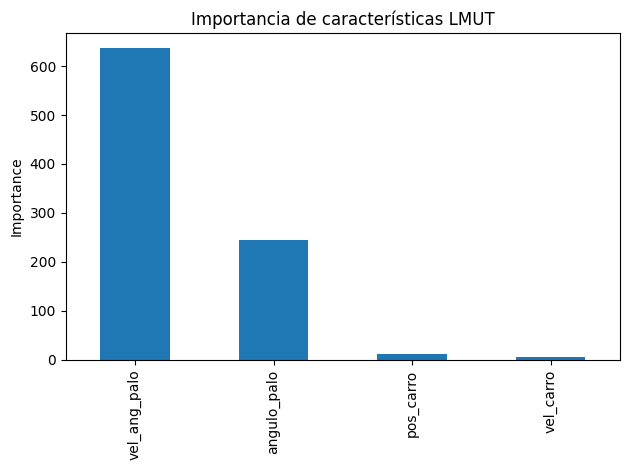

In [154]:
imp = pd.Series(lmut2.feature_influence, index=FEATURE_NAMES).sort_values(ascending=False)
print(imp)

imp.plot(kind="bar", title="Importancia de características LMUT", ylabel="Importance")
plt.tight_layout()
plt.show()
